## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=1)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "vllm_compute_s",
]]


,end_to_end_s,server_roundtrip_s,router_queue_s,vllm_compute_s
count,200.000000,200.000000,200.000000,200.000000
mean,57.795467,56.181367,25.247258,25.497478
std,23.565479,22.952920,21.505428,23.440518
min,11.520083,11.103379,0.048732,0.491463
50%,61.875985,59.775285,24.027480,18.032927
90%,84.396536,82.213598,56.068665,62.693310
99%,112.464290,109.601380,64.114528,96.593244
max,119.024286,116.272725,64.920739,103.313918


In [2]:
df

,idx,req_id,send_failed,wait_wall_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,end_to_end_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_post_result_s,server_roundtrip_s
0,36,98c124a6afae45a390cd8ca919f1c8ff,False,11.523510,11.066161,stop,381,3,384,11.520083,0.416704,0.433301,0.015895,0.000116,11.067440,0.000092,0.002458,0.000765,11.103379
1,12,d088e191fdcc4c69ad5d1e13b5cb8643,False,11.844347,11.608371,stop,319,3,322,11.842530,0.177175,0.211616,0.016350,0.000990,11.609356,0.000055,0.003003,0.001142,11.665354
2,7,82c1ff2cd40e4a8f9ba97da68b4bd7fb,False,11.906017,11.638632,stop,457,4,461,11.903915,0.085120,0.230718,0.016350,0.014168,11.639703,0.000048,0.002461,0.000406,11.818795
3,4,31cd5d2f81ed418d9f0e41607fecda7c,False,14.103474,13.847667,stop,450,3,453,14.100425,0.112029,0.228019,0.015296,0.000104,13.849318,0.000053,0.007111,0.000510,13.988396
4,33,9fd355c57efe46a78bf9cf4742e14718,False,14.045074,13.596580,stop,297,3,300,14.043286,0.404413,0.422870,0.015266,0.000103,13.598464,0.000065,0.004795,0.001712,13.638873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38,c73683fb920b462783383d011ea1c5c6,False,103.938524,103.312795,length,413,2048,2461,103.935939,0.464399,0.590321,0.015841,0.011887,103.313918,0.000147,0.003269,0.000547,103.471540
196,142,4cdd4cea7d2b43bdbe985033db58c39b,False,104.595503,42.861517,stop,276,1482,1758,104.593334,3.253358,61.726610,0.000676,0.000038,42.862381,0.000082,0.003091,0.000450,101.339975
197,119,5a2f0cfd42c643dd9ac5131f3671781a,False,112.450006,57.699725,stop,380,1887,2267,112.447543,2.863583,54.741109,0.000721,0.000050,57.700992,0.000177,0.003970,0.000518,109.583960
198,137,925121e7ea7044cd9d7862b0bfeef1ba,False,114.124772,62.404224,length,382,2048,2430,114.122233,2.796322,51.712594,0.000625,0.000039,62.405280,0.000127,0.003056,0.000505,111.325910


In [3]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# -------- choose experiments to compare --------
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


,exp45_end_to_end_s,exp46_end_to_end_s,exp47_end_to_end_s,exp48_end_to_end_s
count,200.000000,200.000000,200.000000,200.000000
mean,21.470186,21.974968,26.179368,30.639885
std,28.821154,29.404911,30.170252,29.628105
min,0.204597,0.234806,0.380273,0.445352
50%,13.624118,13.754315,17.297868,20.199750
90%,46.452622,44.681255,50.091762,51.741409
99%,100.220087,113.541595,110.335473,140.158287
max,239.579415,242.400117,271.728548,259.435086


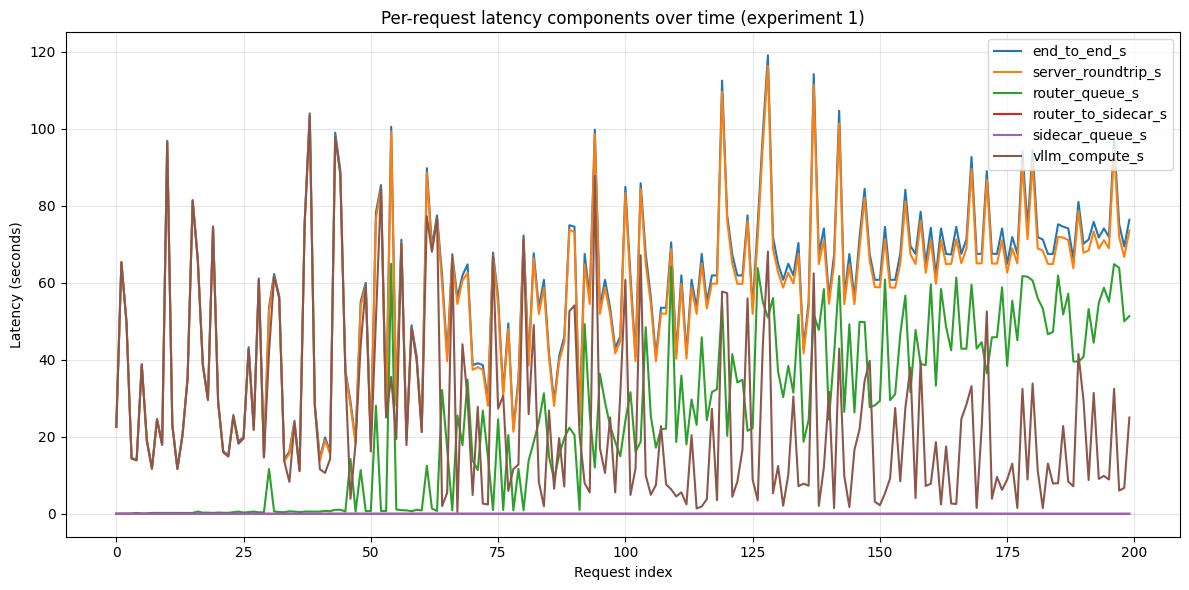

In [4]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 1
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


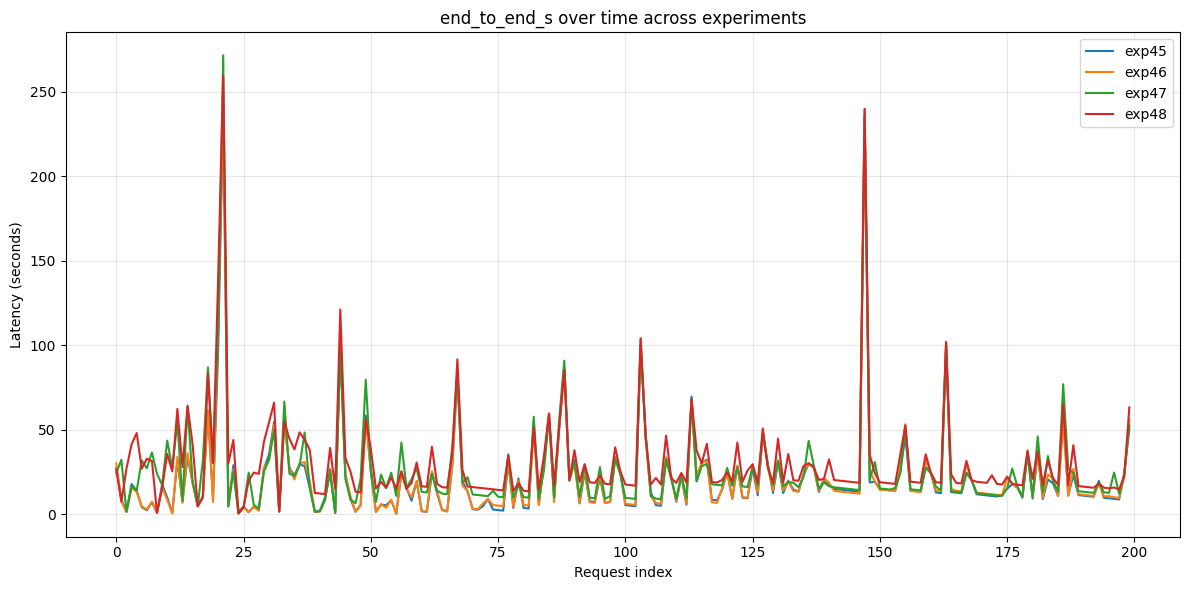

In [5]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"{metric} over time across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Throughput Metrics

In [6]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)
cols = [
    "gen_tokens_per_sec",
    "prefill_tokens_per_sec",
    "requests_running",
    # "requests_waiting",
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
    # "gpu_kv_cache_usage_frac",
    # "cpu_kv_cache_usage_frac",
    #
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",
    #
    # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",
    #
    # spec decode (optional)
    # "spec_tokens_accepted_per_sec",
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # Option 1 (simple): pool all instances together, treat each (tick,instance) as a sample
    # Option 2 (cluster view): sum across instances per tick, then describe the per-tick totals
    # Choose one; default below is cluster view because it's usually what you want when comparing runs.

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    # keeps time granularity, avoids overweighting runs with more instances in the file
    agg = prom.groupby("ts")[cols].sum(min_count=1).reset_index()

    # Describe only selected cols
    summary = (
        agg[cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


,exp45_gen_tokens_per_sec,exp45_prefill_tokens_per_sec,exp45_requests_running,exp45_ttft_seconds_avg,exp45_tpot_seconds_avg,exp46_gen_tokens_per_sec,exp46_prefill_tokens_per_sec,exp46_requests_running,exp46_ttft_seconds_avg,exp46_tpot_seconds_avg,exp47_gen_tokens_per_sec,exp47_prefill_tokens_per_sec,exp47_requests_running,exp47_ttft_seconds_avg,exp47_tpot_seconds_avg,exp48_gen_tokens_per_sec,exp48_prefill_tokens_per_sec,exp48_requests_running,exp48_ttft_seconds_avg,exp48_tpot_seconds_avg
count,252.000000,252.000000,252.000000,57.000000,250.000000,255.000000,255.000000,255.000000,61.000000,251.000000,250.000000,250.000000,250.000000,59.000000,248.000000,255.000000,255.000000,255.000000,58.000000,249.000000
mean,416.086395,55.407298,13.107143,0.835872,0.133062,417.018767,62.150802,13.058824,0.859774,0.132164,414.959023,60.493302,13.432000,0.813975,0.129700,410.303961,61.448284,13.156863,0.943167,0.120646
std,522.820262,150.140092,16.917436,0.752011,0.125644,514.265170,185.441365,16.562233,0.968781,0.124128,515.839196,181.142460,17.361193,1.057774,0.096844,553.920241,197.462663,18.392883,1.285001,0.098960
min,0.000000,0.000000,0.000000,0.130856,0.028923,0.000000,0.000000,0.000000,0.086692,0.028468,0.000000,0.000000,0.000000,0.059965,0.028551,0.000000,0.000000,0.000000,0.079091,0.026685
50%,106.500000,0.000000,3.000000,0.590469,0.084135,105.000000,0.000000,3.000000,0.447409,0.057992,107.000000,0.000000,3.000000,0.449938,0.084030,105.000000,0.000000,3.000000,0.494447,0.058139
90%,1355.394821,186.500000,43.900000,1.700770,0.249970,1383.400000,140.200000,43.600000,2.092510,0.246090,1359.475300,161.900000,49.000000,2.190086,0.244527,1551.200000,145.200000,53.000000,2.014670,0.248544
99%,1722.970000,694.125000,55.000000,3.531284,0.464843,1663.460000,914.700000,52.460000,4.306999,0.581603,1732.180000,957.336440,55.510000,4.710775,0.477689,1800.120000,958.600000,56.460000,6.265940,0.467914
max,1843.000000,1166.438000,57.000000,3.821312,1.439978,1720.000000,1344.000000,54.000000,5.296116,1.201292,1778.000000,1276.012000,58.000000,5.724911,0.638848,1850.000000,1696.150000,59.000000,7.108553,0.665715


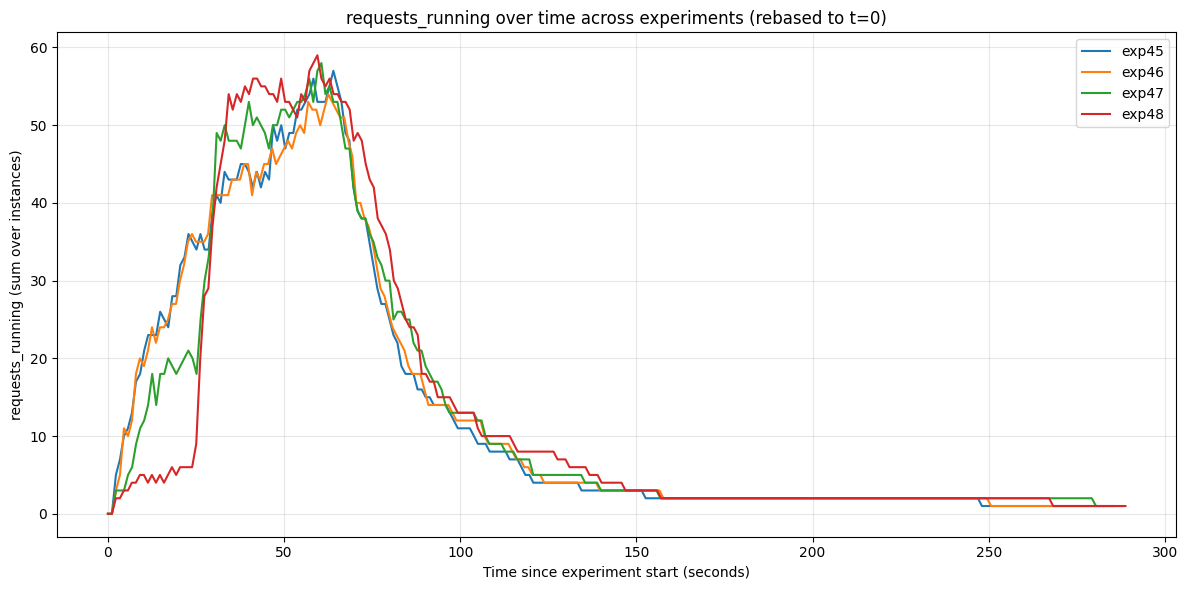

In [7]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]

# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

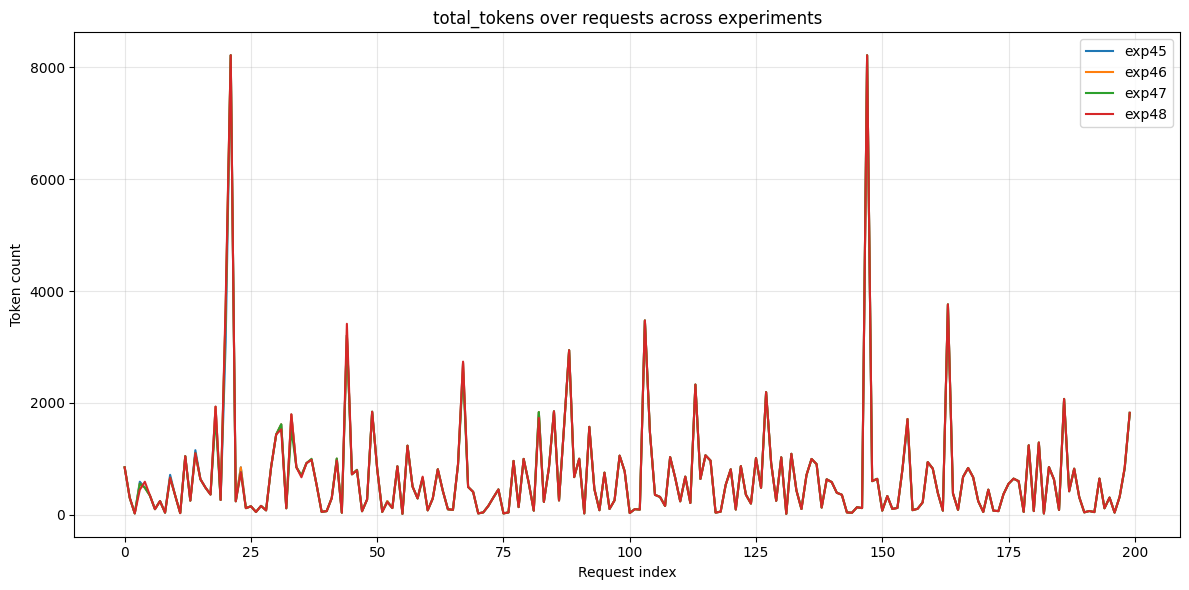

In [8]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


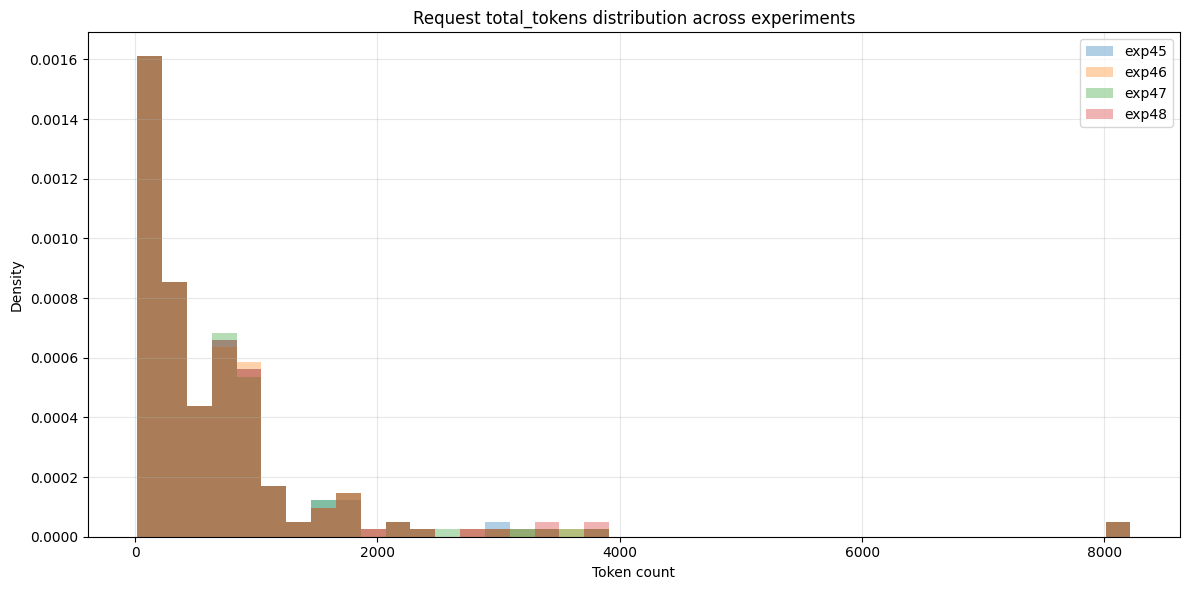

In [9]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
experiments = [45, 46, 47, 48]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


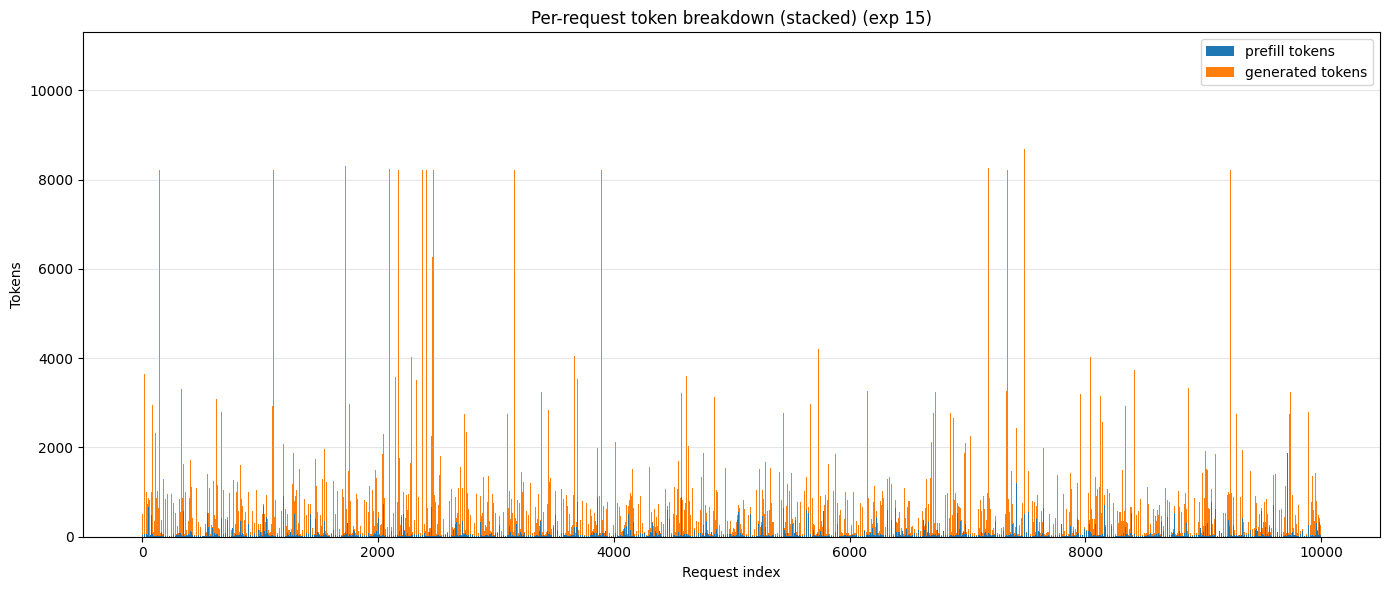

In [10]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose ONE experiment ----
exp_id = 15
# ------------------------------

# ---- plotting controls ----
max_requests_to_plot = 10000   # set None to plot all (can get slow/cluttered)

# ---- choose what to show (uncomment as needed) ----
show_prefill = True
show_generated = True
# show_prefill = True;  show_generated = False   # only prefill
# show_prefill = False; show_generated = True    # only generated
# -----------------------------------------------

df = (
    load_experiment_latencies(exp_id=exp_id)
    .sort_values("idx")
    .reset_index(drop=True)
)

# Pull columns if present
x = pd.to_numeric(df.get("idx"), errors="coerce")

prefill = None
gen = None

if show_prefill:
    prefill = pd.to_numeric(df.get("prompt_tokens"), errors="coerce")
    if "prompt_tokens" not in df.columns:
        print("WARN: prompt_tokens not found; disabling prefill plot.")
        show_prefill = False

if show_generated:
    # support either completion_tokens or output_tokens naming
    if "completion_tokens" in df.columns:
        gen = pd.to_numeric(df["completion_tokens"], errors="coerce")
    elif "output_tokens" in df.columns:
        gen = pd.to_numeric(df["output_tokens"], errors="coerce")
    else:
        print("WARN: completion_tokens/output_tokens not found; disabling generated plot.")
        show_generated = False

if not show_prefill and not show_generated:
    raise RuntimeError("Nothing to plot: both prefill and generated are disabled or missing.")

# Build mask of valid rows depending on what is enabled
mask = x.notna()
if show_prefill and prefill is not None:
    mask &= prefill.notna()
if show_generated and gen is not None:
    mask &= gen.notna()

x = x[mask].astype(int).values
prefill_vals = prefill[mask].values if (show_prefill and prefill is not None) else None
gen_vals = gen[mask].values if (show_generated and gen is not None) else None

# Trim if requested
if max_requests_to_plot is not None and len(x) > max_requests_to_plot:
    x = x[:max_requests_to_plot]
    if prefill_vals is not None:
        prefill_vals = prefill_vals[:max_requests_to_plot]
    if gen_vals is not None:
        gen_vals = gen_vals[:max_requests_to_plot]

plt.figure(figsize=(14, 6))

# Plot variants
if show_prefill and show_generated:
    # Stacked bars: prefill at bottom, generated on top
    plt.bar(x, prefill_vals, label="prefill tokens")
    plt.bar(x, gen_vals, bottom=prefill_vals, label="generated tokens")
    title = "Per-request token breakdown (stacked)"
elif show_prefill:
    plt.bar(x, prefill_vals, label="prefill tokens")
    title = "Per-request prefill tokens"
else:
    plt.bar(x, gen_vals, label="generated tokens")
    title = "Per-request generated tokens"

plt.xlabel("Request index")
plt.ylabel("Tokens")
plt.title(f"{title} (exp {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
